In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
patients=pd.read_csv('/content/indian_liver_patient.csv')

In [ ]:
patients.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
patients.shape

(583, 11)

In [ ]:
patients['Gender']=patients['Gender'].apply(lambda x:1 if x=='Male' else 0)

In [ ]:
patients.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


<Axes: xlabel='Gender'>

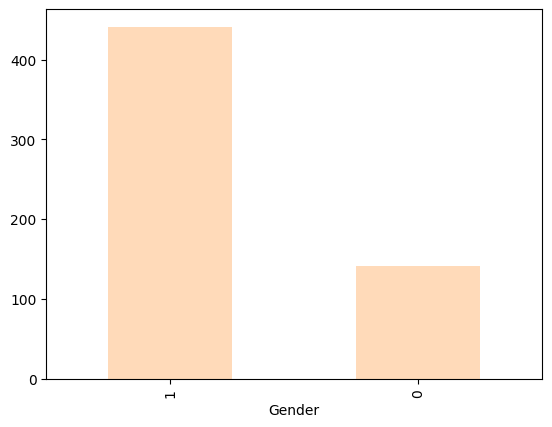

In [ ]:
patients['Gender'].value_counts().plot.bar(color='peachpuff')
#number of male and female using a countplot

<Axes: xlabel='Dataset'>

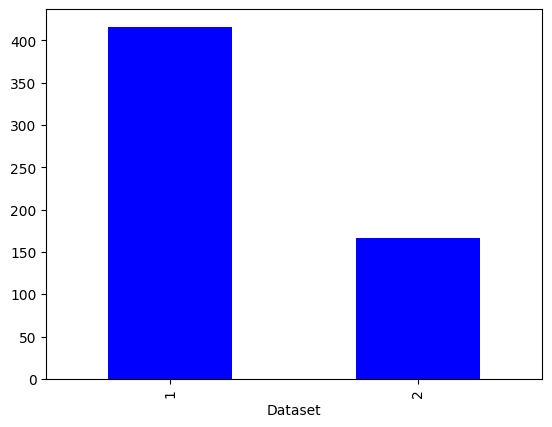

In [ ]:
patients['Dataset'].value_counts().plot.bar(color='blue')
#countplot of our Dataset column

In [ ]:
patients.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,4


In [ ]:
patients['Albumin_and_Globulin_Ratio'].mean()

np.float64(0.9470639032815197)

In [ ]:
patients=patients.fillna(0.94)

In [ ]:
patients.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,4


<Axes: xlabel='Age'>

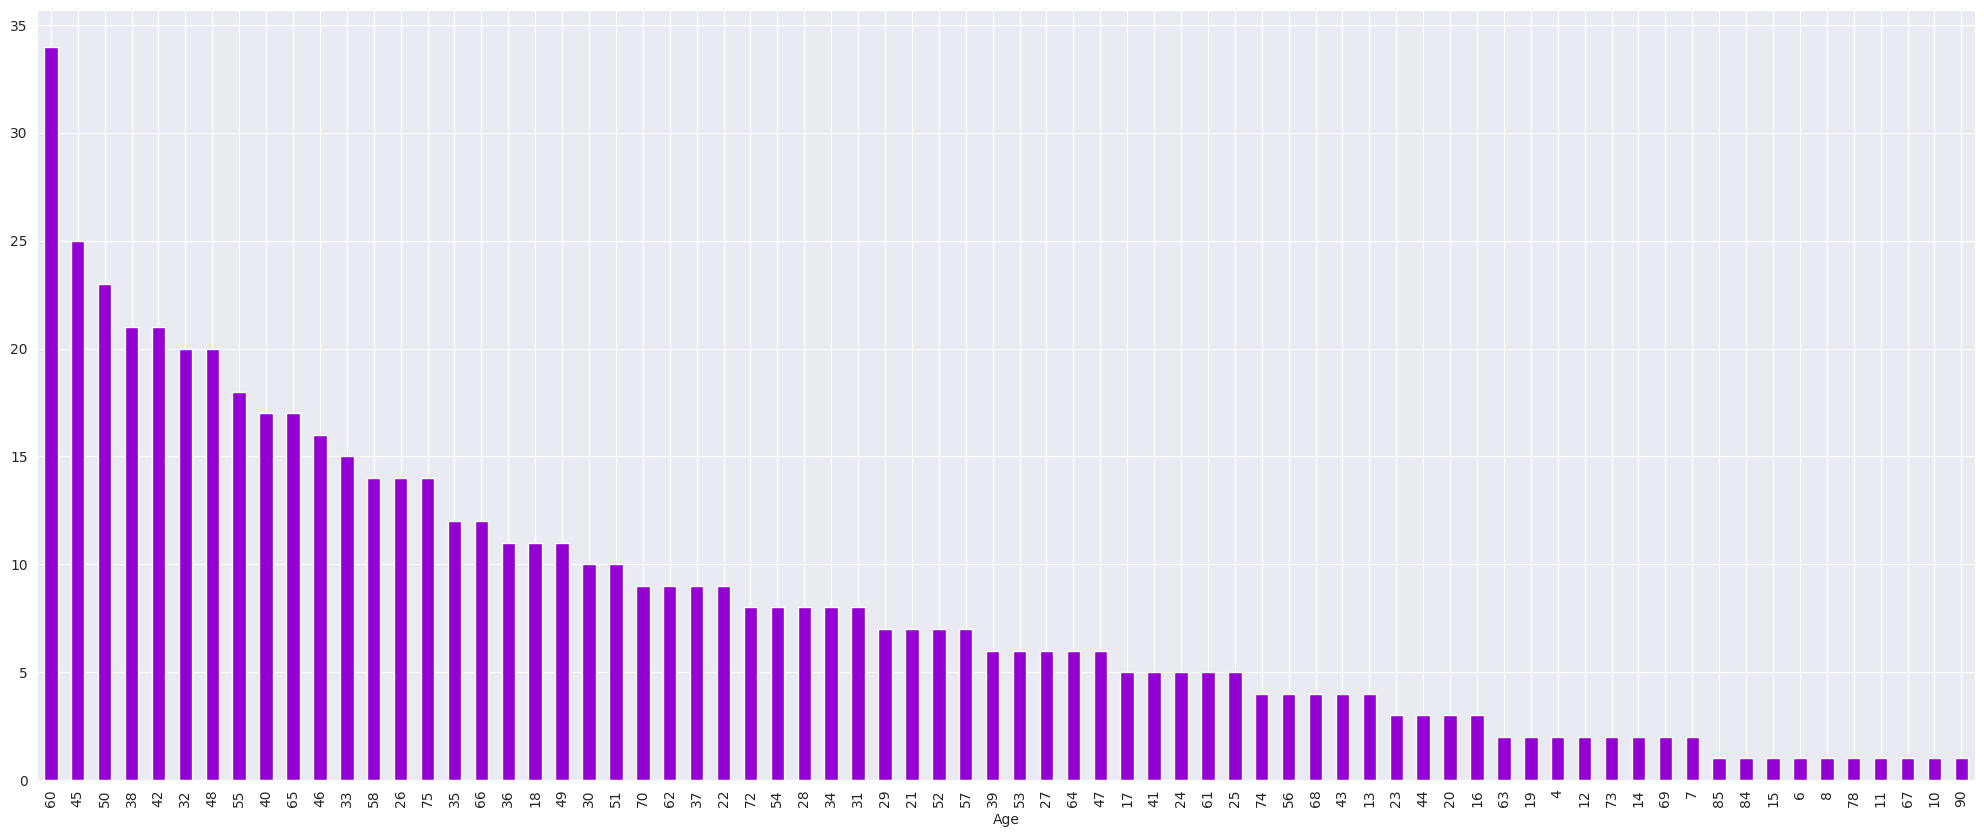

In [ ]:
sns.set_style('darkgrid')
plt.figure(figsize=(25,10))
patients['Age'].value_counts().plot.bar(color='darkviolet')
#age group of the patients

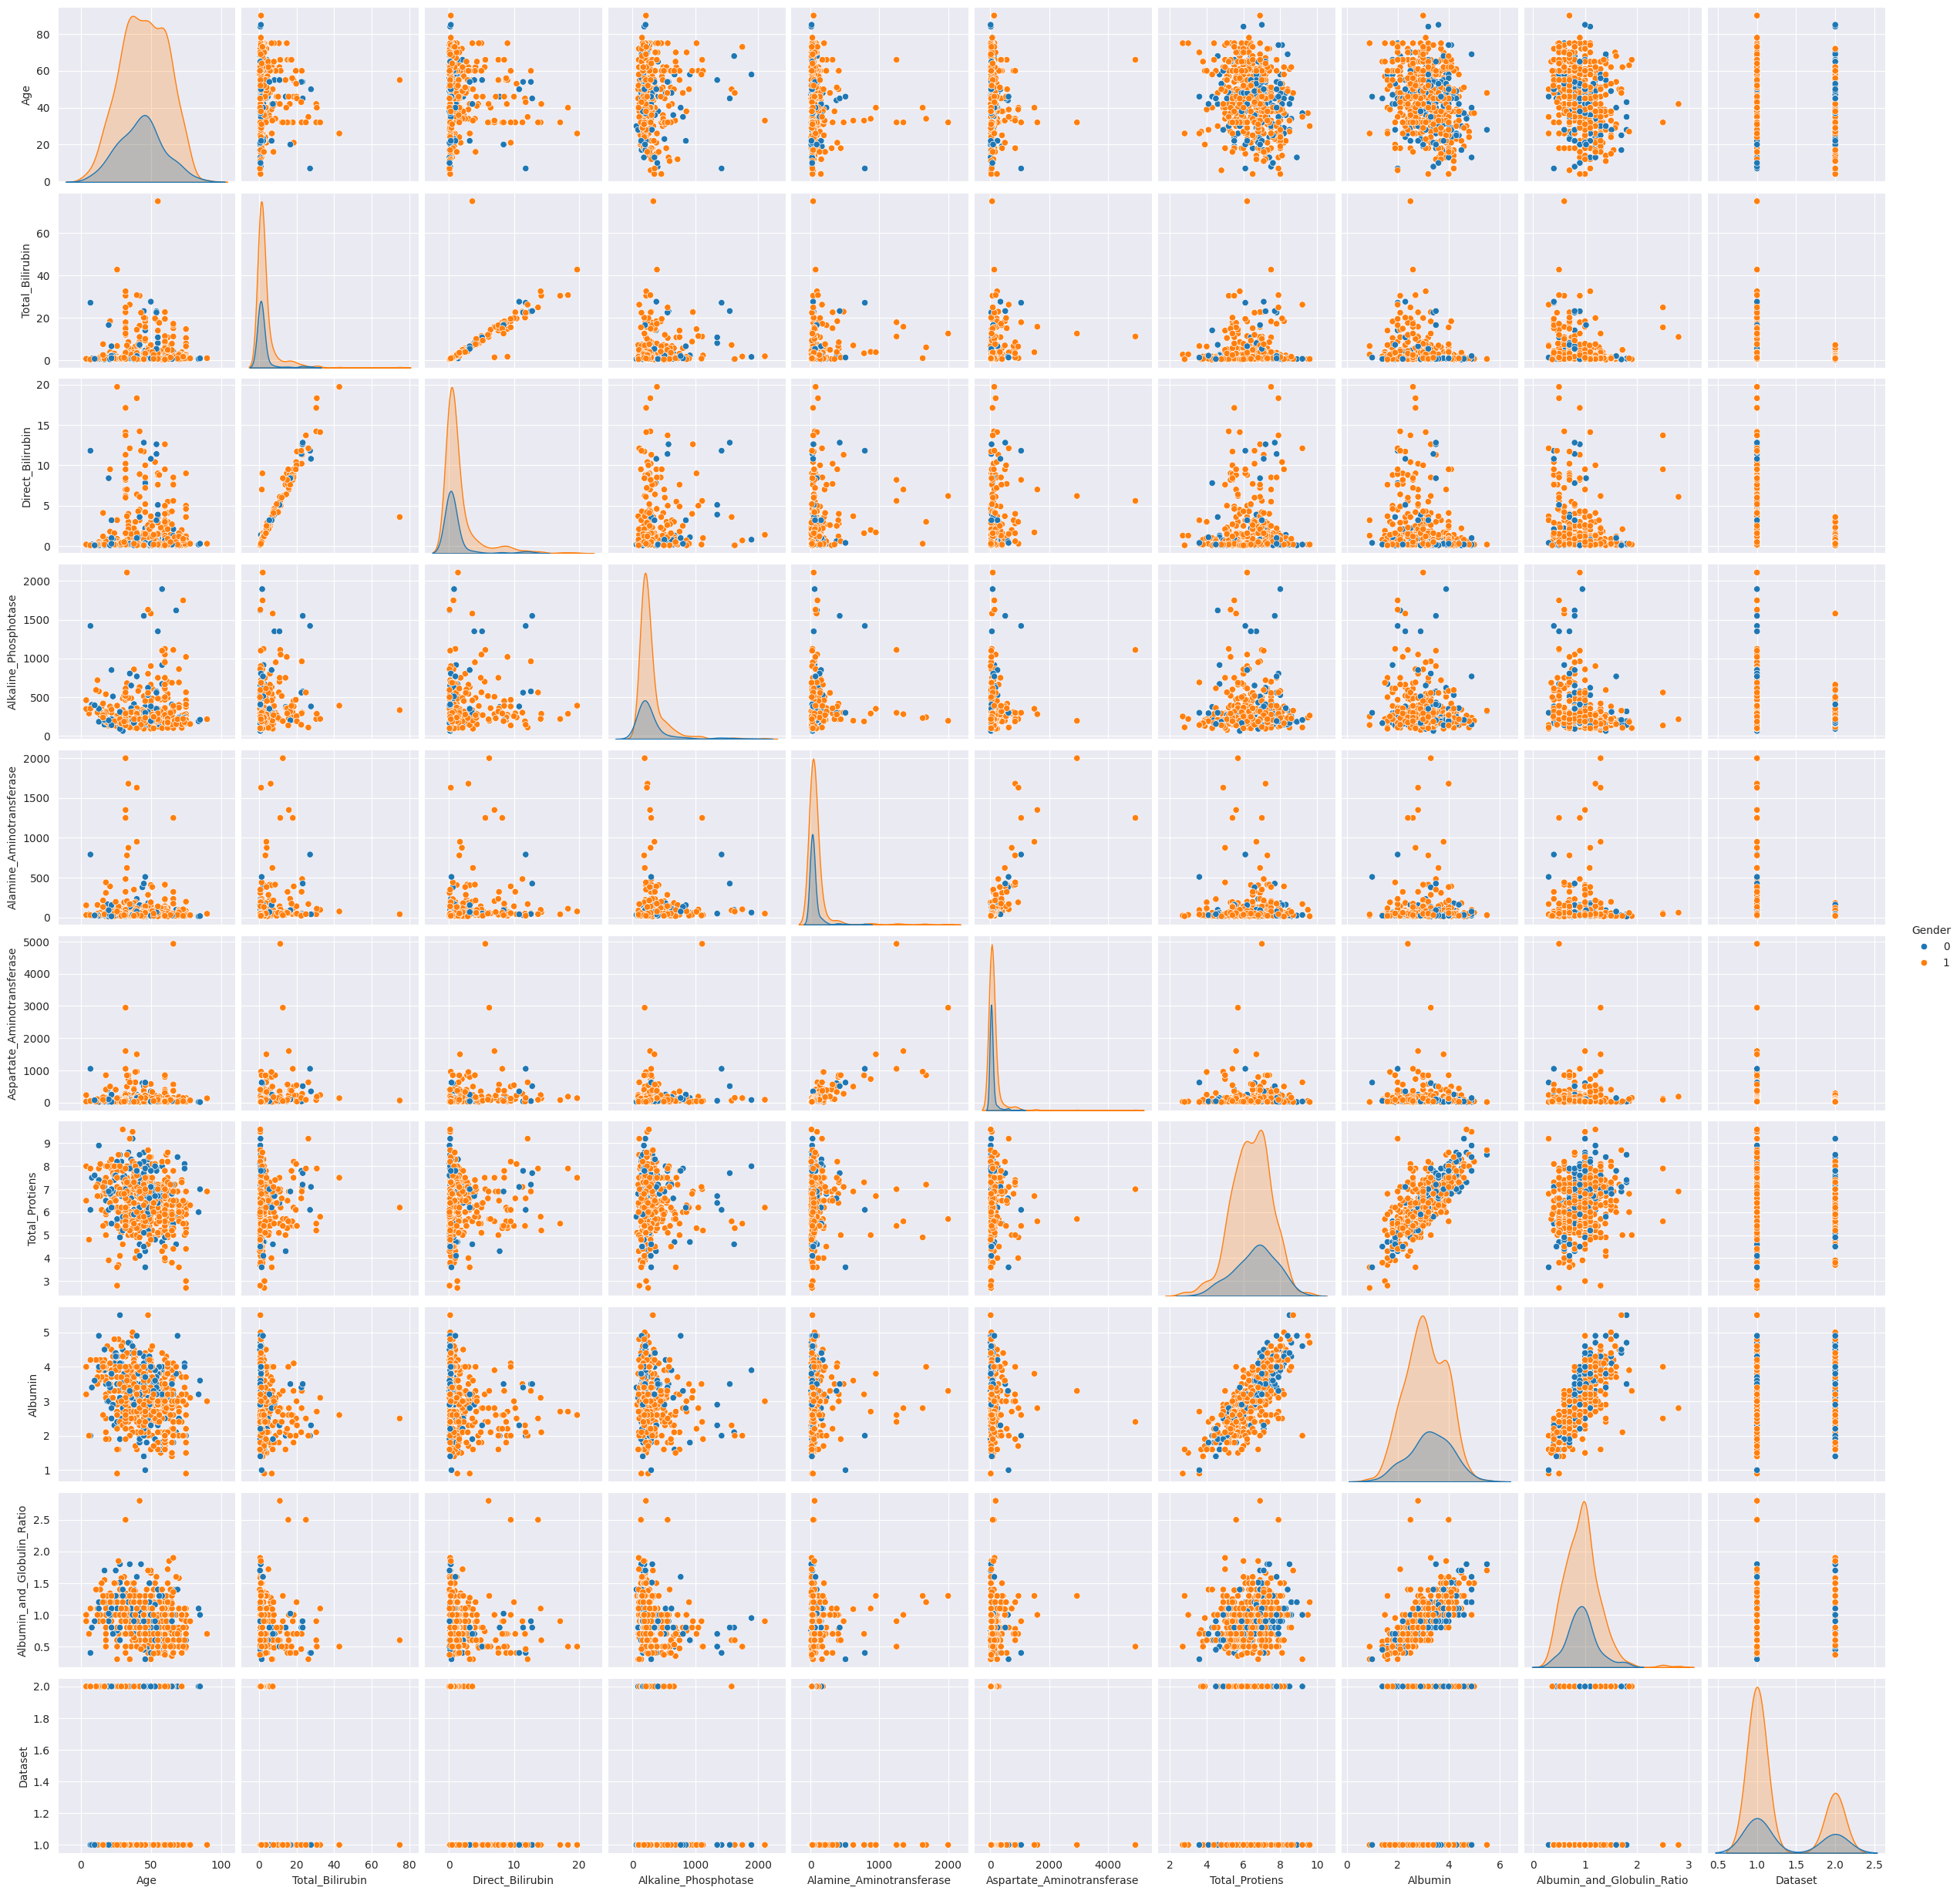

In [ ]:
plt.rcParams['figure.figsize']=(10,10)
sns.pairplot(patients,hue='Gender')
# pairplot of patients based on Gender

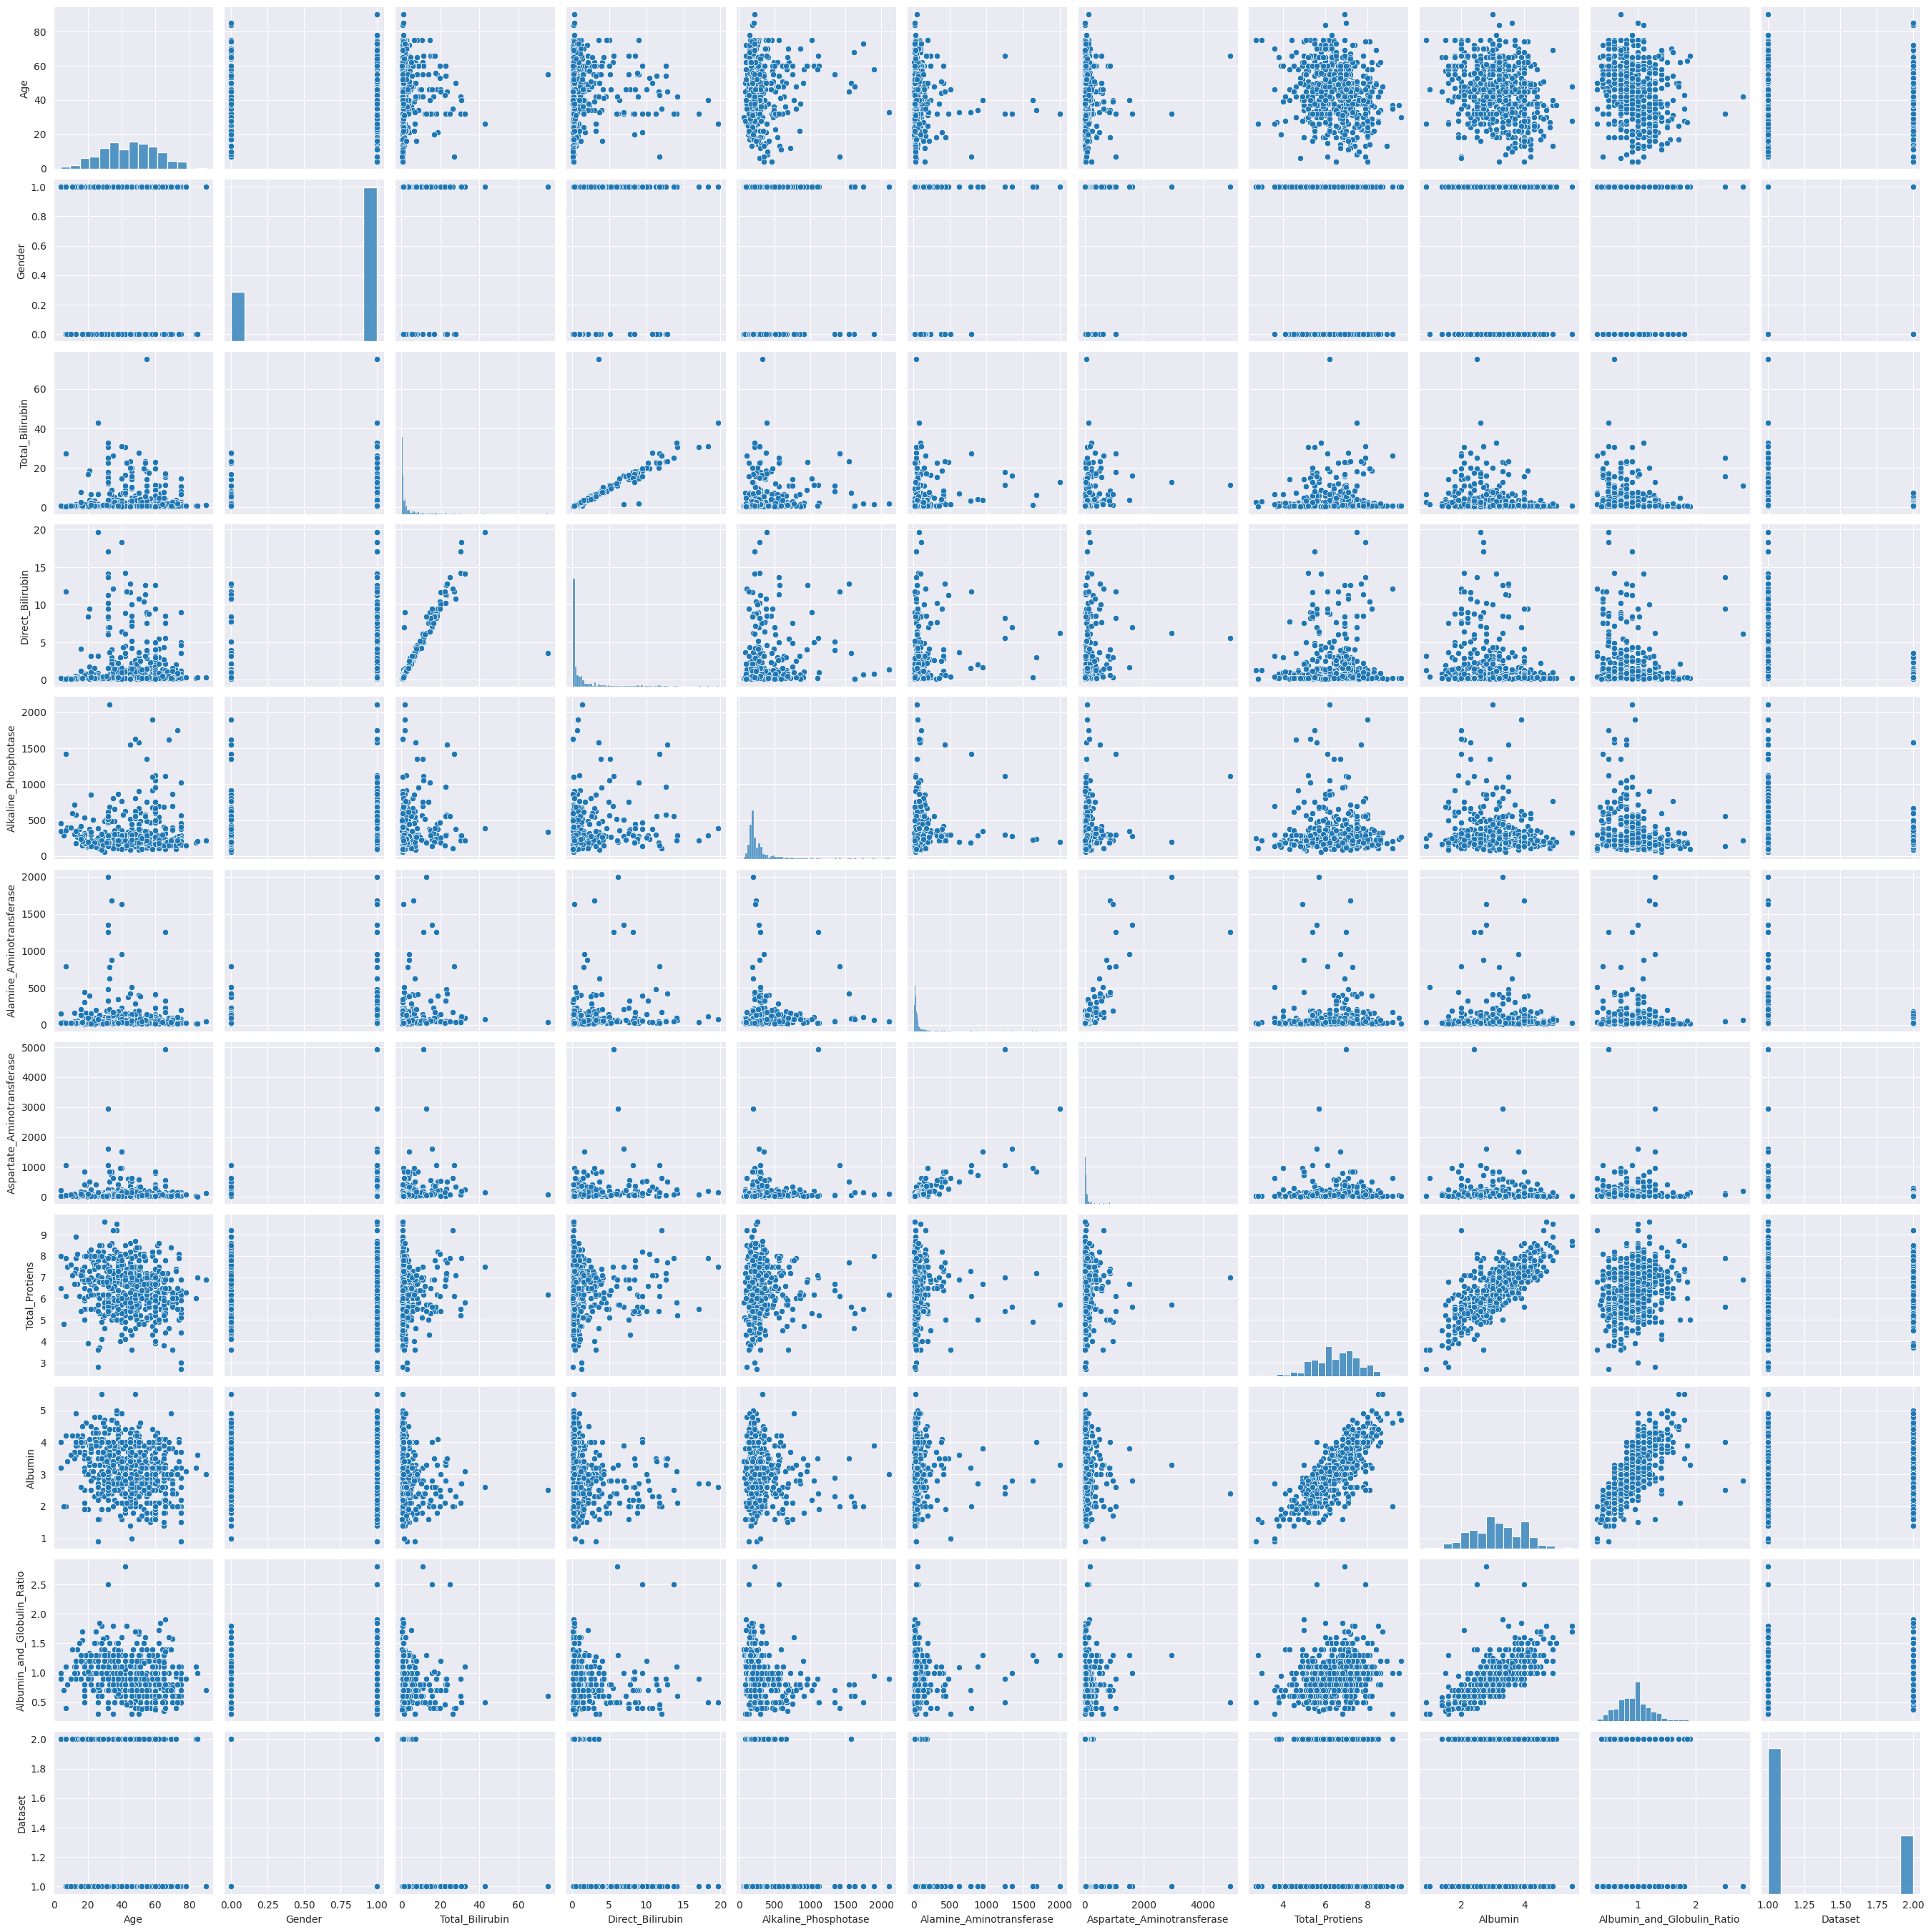

In [ ]:
sns.pairplot(patients)

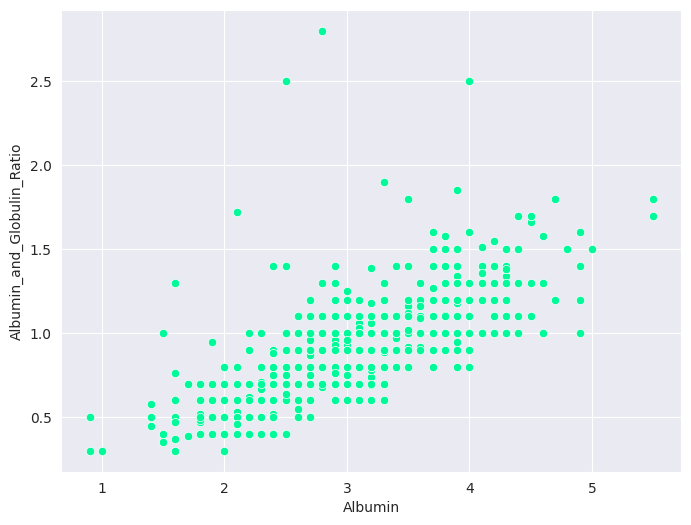

In [ ]:
f, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x="Albumin", y="Albumin_and_Globulin_Ratio",color='mediumspringgreen',data=patients);
plt.show()
#compare the albumin and albumin and globulin ratio by a scatterplot

<Axes: xlabel='Gender'>

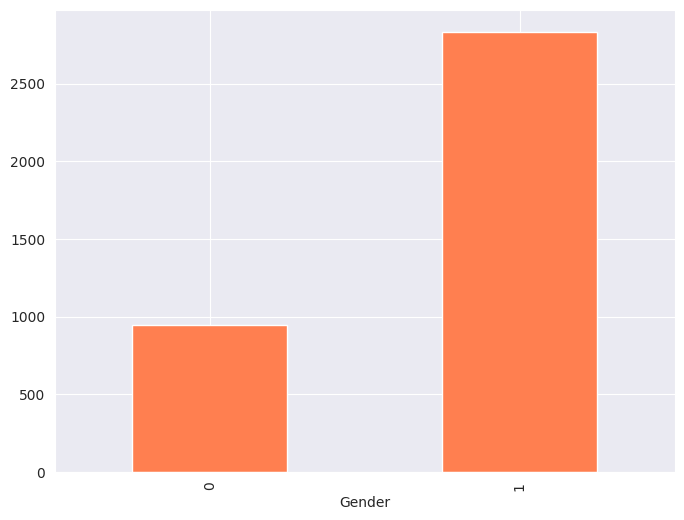

In [ ]:
plt.figure(figsize=(8,6))
patients.groupby('Gender').sum()["Total_Protiens"].plot.bar(color='coral')
#ompare the Gender based on the Protein Intake.

<Axes: xlabel='Gender'>

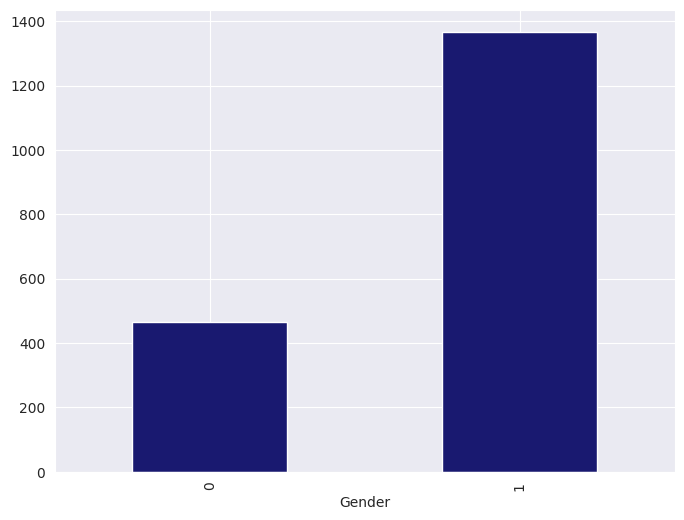

In [ ]:
plt.figure(figsize=(8,6))
patients.groupby('Gender').sum()['Albumin'].plot.bar(color='midnightblue')
#compare male and female based on Albumin Level.

<Axes: xlabel='Gender'>

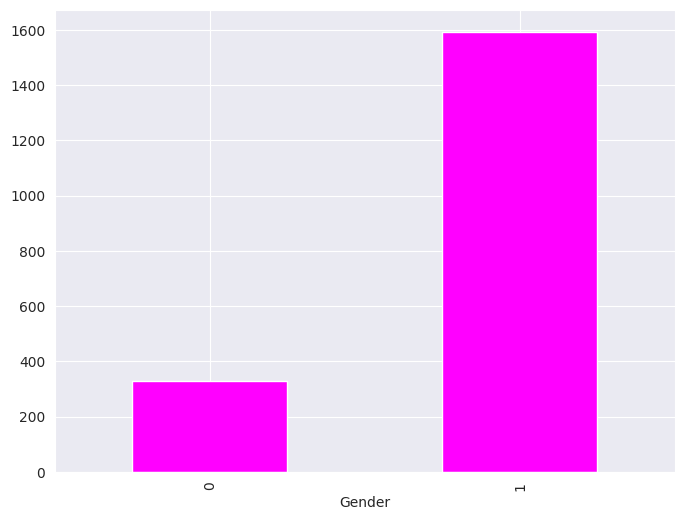

In [ ]:
plt.figure(figsize=(8,6))
patients.groupby('Gender').sum()['Total_Bilirubin'].plot.bar(color='fuchsia')
#ompare them based on the Bilirubin content

In [ ]:
corr=patients.corr()

<Axes: >

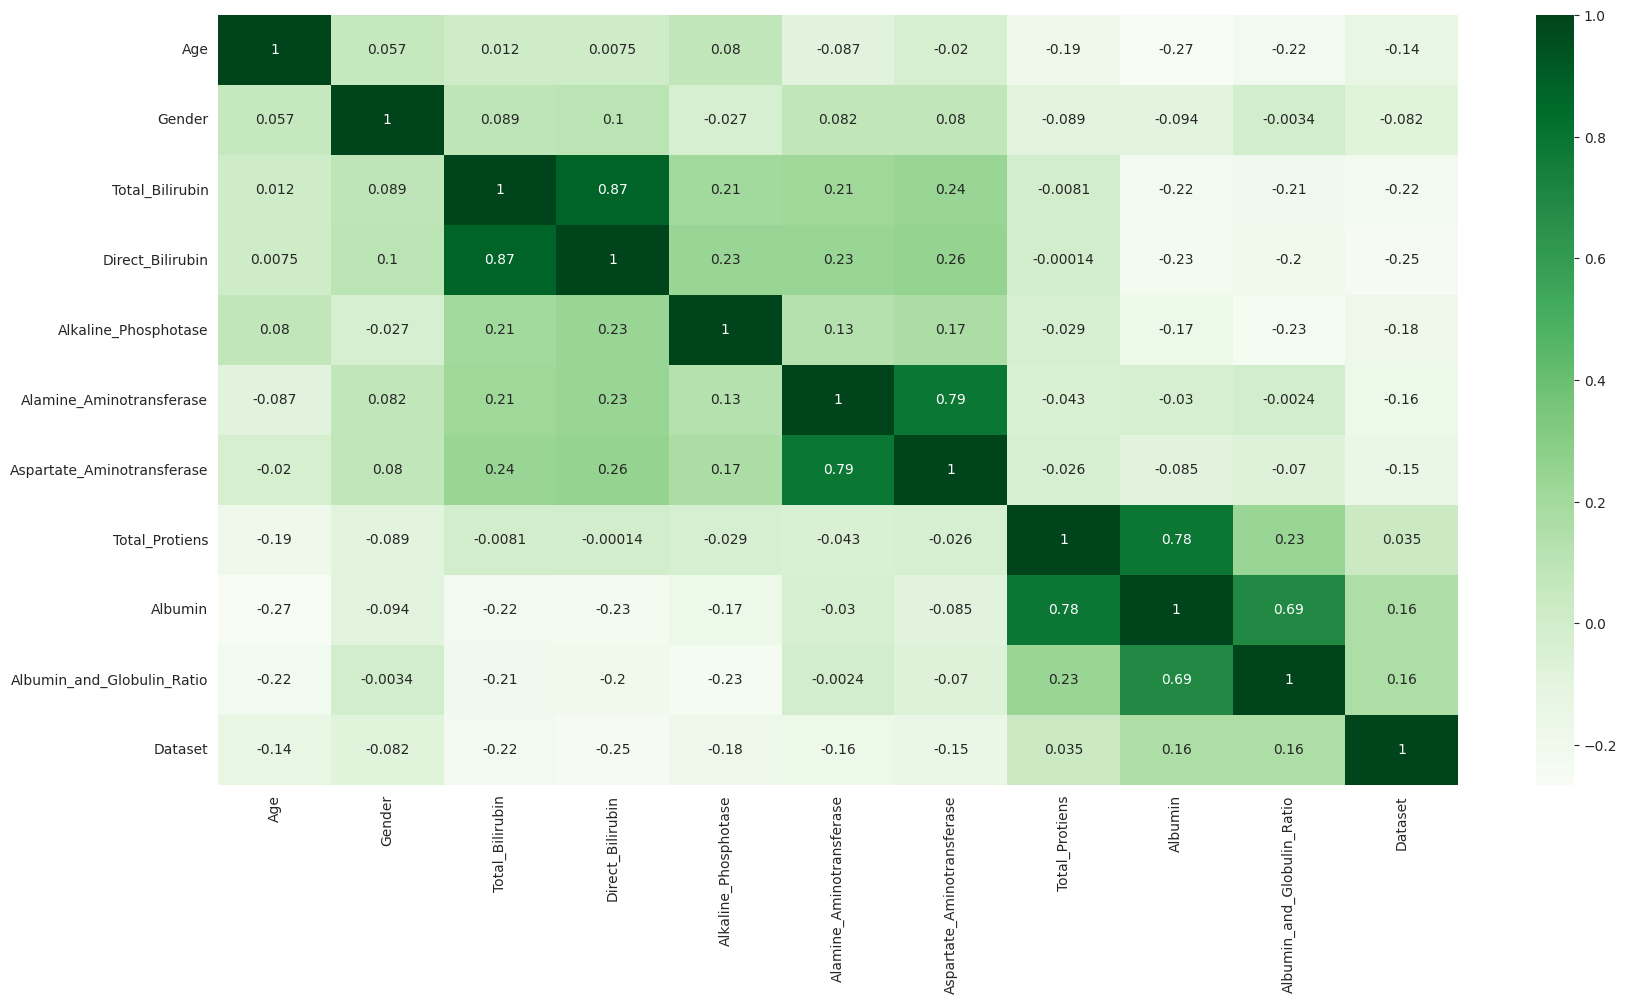

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(corr,cmap="Greens",annot=True)
#correlation between the features using a heatmap:

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
patients.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

In [ ]:
X=patients[['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio']]
y=patients['Dataset']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=123)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score

# Define the k-fold cross-validator
kfold = KFold(n_splits=5, random_state=42, shuffle=True)

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Perform cross-validation
results = cross_val_score(rf_model, X_train, y_train, cv=kfold)

# Print the results
print(results)
print("Accuracy:", results.mean() * 100)


[0.73170732 0.7195122  0.74390244 0.66666667 0.67901235]
Accuracy: 70.81601927130382


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Define the k-fold cross-validator
kfold = KFold(n_splits=5, random_state=42, shuffle=True)

# Initialize KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Perform cross-validation
results = cross_val_score(knn_model, X_train, y_train, cv=kfold)

# Print the results
print(results)
print("Accuracy:", results.mean() * 100)


[0.64516129 0.75268817 0.64516129 0.60869565 0.73913043]
Accuracy: 67.81673679289388


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define the k-fold cross-validator
kfold = KFold(n_splits=5, random_state=42, shuffle=True)

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Feature scaling
    ('logmodel', LogisticRegression(solver='liblinear', max_iter=1000))  # Logistic Regression model
])

# Define the parameter grid
param_grid = {
    'logmodel__C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'logmodel__penalty': ['l1', 'l2'],  # Regularization type
}

# Define the GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='accuracy')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_ * 100)


Best parameters found:  {'logmodel__C': 0.1, 'logmodel__penalty': 'l1'}
Best cross-validation accuracy:  71.05890603085554


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, KFold

# Define the k-fold cross-validator
kfold = KFold(n_splits=5, random_state=42, shuffle=True)

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Define the parameter grid
param_grid = {
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Define the GridSearchCV
grid_search = GridSearchCV(dt_model, param_grid, cv=kfold, scoring='accuracy')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_ * 100)


Best parameters found:  {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best cross-validation accuracy:  66.40469738030713


Accuracy: 89.50%


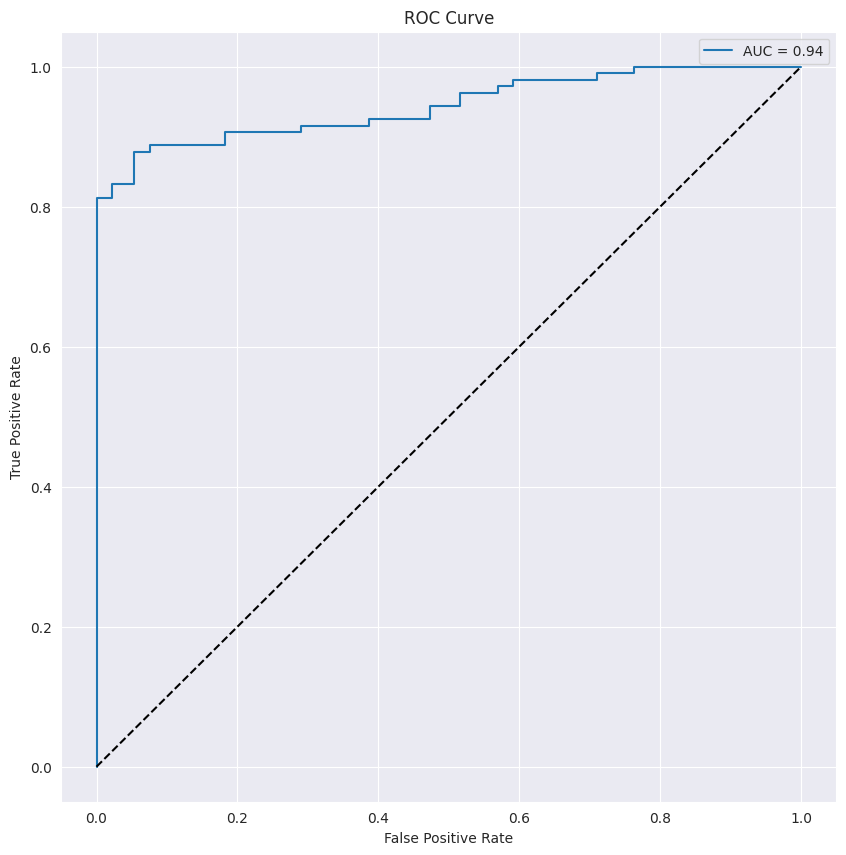

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.datasets import make_classification

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train XGBoost model
xgboost_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgboost_model.fit(X_train, y_train)

# Predict probabilities and classes
y_prob = xgboost_model.predict_proba(X_test)[:, 1]
y_pred = xgboost_model.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Compute AUC and ROC curve
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import joblib
import xgboost as xgb
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
dataset_path = "/content/indian_liver_patient.csv"  # Change to correct path
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset file '{dataset_path}' not found!")

# Load the dataset
df = pd.read_csv(dataset_path)

# Preprocess Data
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})  # Convert Gender to 0/1
df = df.dropna()  # Remove missing values

# Define features and target variable
X = df.drop(columns=['Dataset'])  # 'Dataset' column: 1 = Disease, 2 = No Disease
y = df['Dataset'].apply(lambda x: 1 if x == 1 else 0)  # Convert to binary (1 = Disease, 0 = No Disease)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train XGBoost Model
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")
model.fit(X_train, y_train)

# Save model
model_filename = "liver_disease_xgboost.pkl"
joblib.dump((model, scaler), model_filename)
print(f"Model saved as {model_filename}")

# Evaluate Model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
#print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Function to get user input
def get_user_input():
    """Collect user input for prediction."""
    print("\nEnter the following details for liver disease prediction:")

    try:
        age = float(input("Age: "))
        gender = input("Gender (Male=1, Female=0): ").strip()
        if gender not in ['0', '1']:
            raise ValueError("Invalid gender input. Please enter 1 for Male or 0 for Female.")
        gender = float(gender)

        tb = float(input("Total Bilirubin: "))
        db = float(input("Direct Bilirubin: "))
        alkphos = float(input("Alkaline Phosphatase: "))
        sgpt = float(input("Alamine Aminotransferase (SGPT): "))
        sgot = float(input("Aspartate Aminotransferase (SGOT): "))
        tp = float(input("Total Proteins: "))
        alb = float(input("Albumin: "))
        agratio = float(input("Albumin/Globulin Ratio: "))

    except ValueError as e:
        print(f"Input error: {e}")
        return None

    return np.array([[age, gender, tb, db, alkphos, sgpt, sgot, tp, alb, agratio]])

# Function to make predictions
def make_prediction(user_data):
    """Make prediction using the trained model."""
    try:
        # Load trained model
        model, scaler = joblib.load(model_filename)

        # Scale user input
        user_data_scaled = scaler.transform(user_data)

        # Get prediction
        y_prob = model.predict_proba(user_data_scaled)[:, 1]  # Probability of disease
        prediction = model.predict(user_data_scaled)

        # Display results
        print(f"\nPrediction Probability: {y_prob[0]:.2f}")
        return "Liver Disease Detected" if prediction[0] == 1 else "No Liver Disease Detected"

    except Exception as e:
        print("Error during prediction:", e)
        return "Prediction failed. Please check input values."

# Run Prediction
if __name__ == "__main__":
    user_data = get_user_input()
    if user_data is not None:
        result = make_prediction(user_data)
        print("Prediction:", result)


Model saved as liver_disease_xgboost.pkl
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.27      0.38        33
           1       0.76      0.94      0.84        83

    accuracy                           0.75       116
   macro avg       0.70      0.61      0.61       116
weighted avg       0.73      0.75      0.71       116


Enter the following details for liver disease prediction:
Age: 55
Gender (Male=1, Female=0): 0
Total Bilirubin: 7.6
Direct Bilirubin: 8
Alkaline Phosphatase: 1
Alamine Aminotransferase (SGPT): 2
Aspartate Aminotransferase (SGOT): 6
Total Proteins: 0.8
Albumin: 4
Albumin/Globulin Ratio: 0.9

Prediction Probability: 0.97
Prediction: Liver Disease Detected
